# [LAB-07] 7. 사후검정

## #01. 준비작업

### 1. 라이브러리 참조

In [2]:
from jussam import load_data
from helper import *
from pandas import pivot, pivot_table
# 사후검정을 위한 라이브러리
from pingouin import pairwise_tukey, pairwise_gameshowell

# 시각화 라이브러리
from statannotations.Annotator import Annotator

📦 연세대학교 주영아 교수가 제작한 라이브러리를 사용중입니다.
📧 Email(1): j.purplerose@yonsei.ac.kr
📧 Email(2): j.purplerose@gmail.com
📝 Website: https://juyounga.kr/


### 2. 데이터 가져오기

- **tree_weight**: 앞 단원에서 ANOVA 분석에 사용한 소나무 품종별 무게 데이터 셋

In [2]:
origin = load_data('tree_weight')
origin.head()

📚 소나무 품종별 무게를 조사한 데이터 (출처: 방송통신대학교 통계학개론)


,weight,group
0,4.170,A
1,5.580,A
2,5.180,A
3,6.110,A
4,4.500,A


## #02. 사후검정 (post hoc)

### 1. 투키의 HSD

- **Tuckey's Honestly Significant Difference** = "진정으로 유의미한 차이"
  - **`OO`(명목형)에 따른 `ㅁㅁ`(연속형)의 차이**라는 의미로 접근한다.
  - **데이터가 등분산성을 만족할 경우 수행**한다.

In [3]:
tukeydf = pairwise_tukey(data=origin, dv='weight', between='group')
tukeydf

,A,B,mean_A,mean_B,diff,se,T,p_tukey,hedges
0,A,B,5.032,4.661,0.371,0.279,1.331,0.391,0.510
1,A,C,5.032,5.526,-0.494,0.279,-1.772,0.198,-0.914
2,B,C,4.661,5.526,-0.865,0.279,-3.103,0.012,-1.289


> 사후 분석 결과, B와 C 집단의 평균 차이만 통계적으로 유의하였다. ($p < 0.05$)    
> 두 집단의 평균은 각각 4.66과 5.53으로 평균 차이는 -0.87이었으며, 효과크기(Hedges' g)는 -1.29로 큰 수준이었다.     
> 즉, C 집단의 평균이 B 집단보다 유의하게 높았다.    
> 반면 A와 B($p \geq 0.05$)와 A와 C($p \geq 0.05$)의 평균 차이는 통계적으로 유의하지 않았다.

### [2] Games-Howell 검정

- **Games-Howell** 검정은 다수의 그룹 간의 평균 차이를 비교하는 통계적 방법 중 하나로, 등분산성 가정이 만족되지 않을 때 사용한다.
  - 이 예제에 적합한 방법은 아니지만 소스코드의 제시를 목적으로 사용한다.

In [4]:
howelldf = pairwise_gameshowell(data=origin, dv='weight', between='group')
howelldf

,A,B,mean_A,mean_B,diff,se,T,df,pval,hedges
0,A,B,5.032,4.661,0.371,0.311,1.191,16.524,0.475,0.510
1,A,C,5.032,5.526,-0.494,0.231,-2.134,16.786,0.113,-0.914
2,B,C,4.661,5.526,-0.865,0.287,-3.010,14.104,0.024,-1.289


## #03. 사후검정 결과 시각화 (statannotations)

### 1. 그룹 순서 추출

In [5]:
order = sorted(origin['group'].unique())
order

['A', 'B', 'C']

### 2. 비교 대상 그룹 쌍 추출

- A열과 B열을 짝지어 (그룹1, 그룹2) 형태로 묶는다

In [6]:
pairs = list(zip(tukeydf['A'], tukeydf['B']))
pairs

[('A', 'B'), ('A', 'C'), ('B', 'C')]

### 3. 각 그룹 쌍에 대응하는 p값 추출

In [7]:
pvalues = list(tukeydf['p_tukey'])
pvalues

[0.39087114420210534, 0.1979959912995718, 0.012006423979493142]

### 4. 시각화 구현

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

A vs. B: Custom statistical test, P_val:3.909e-01
B vs. C: Custom statistical test, P_val:1.201e-02
A vs. C: Custom statistical test, P_val:1.980e-01


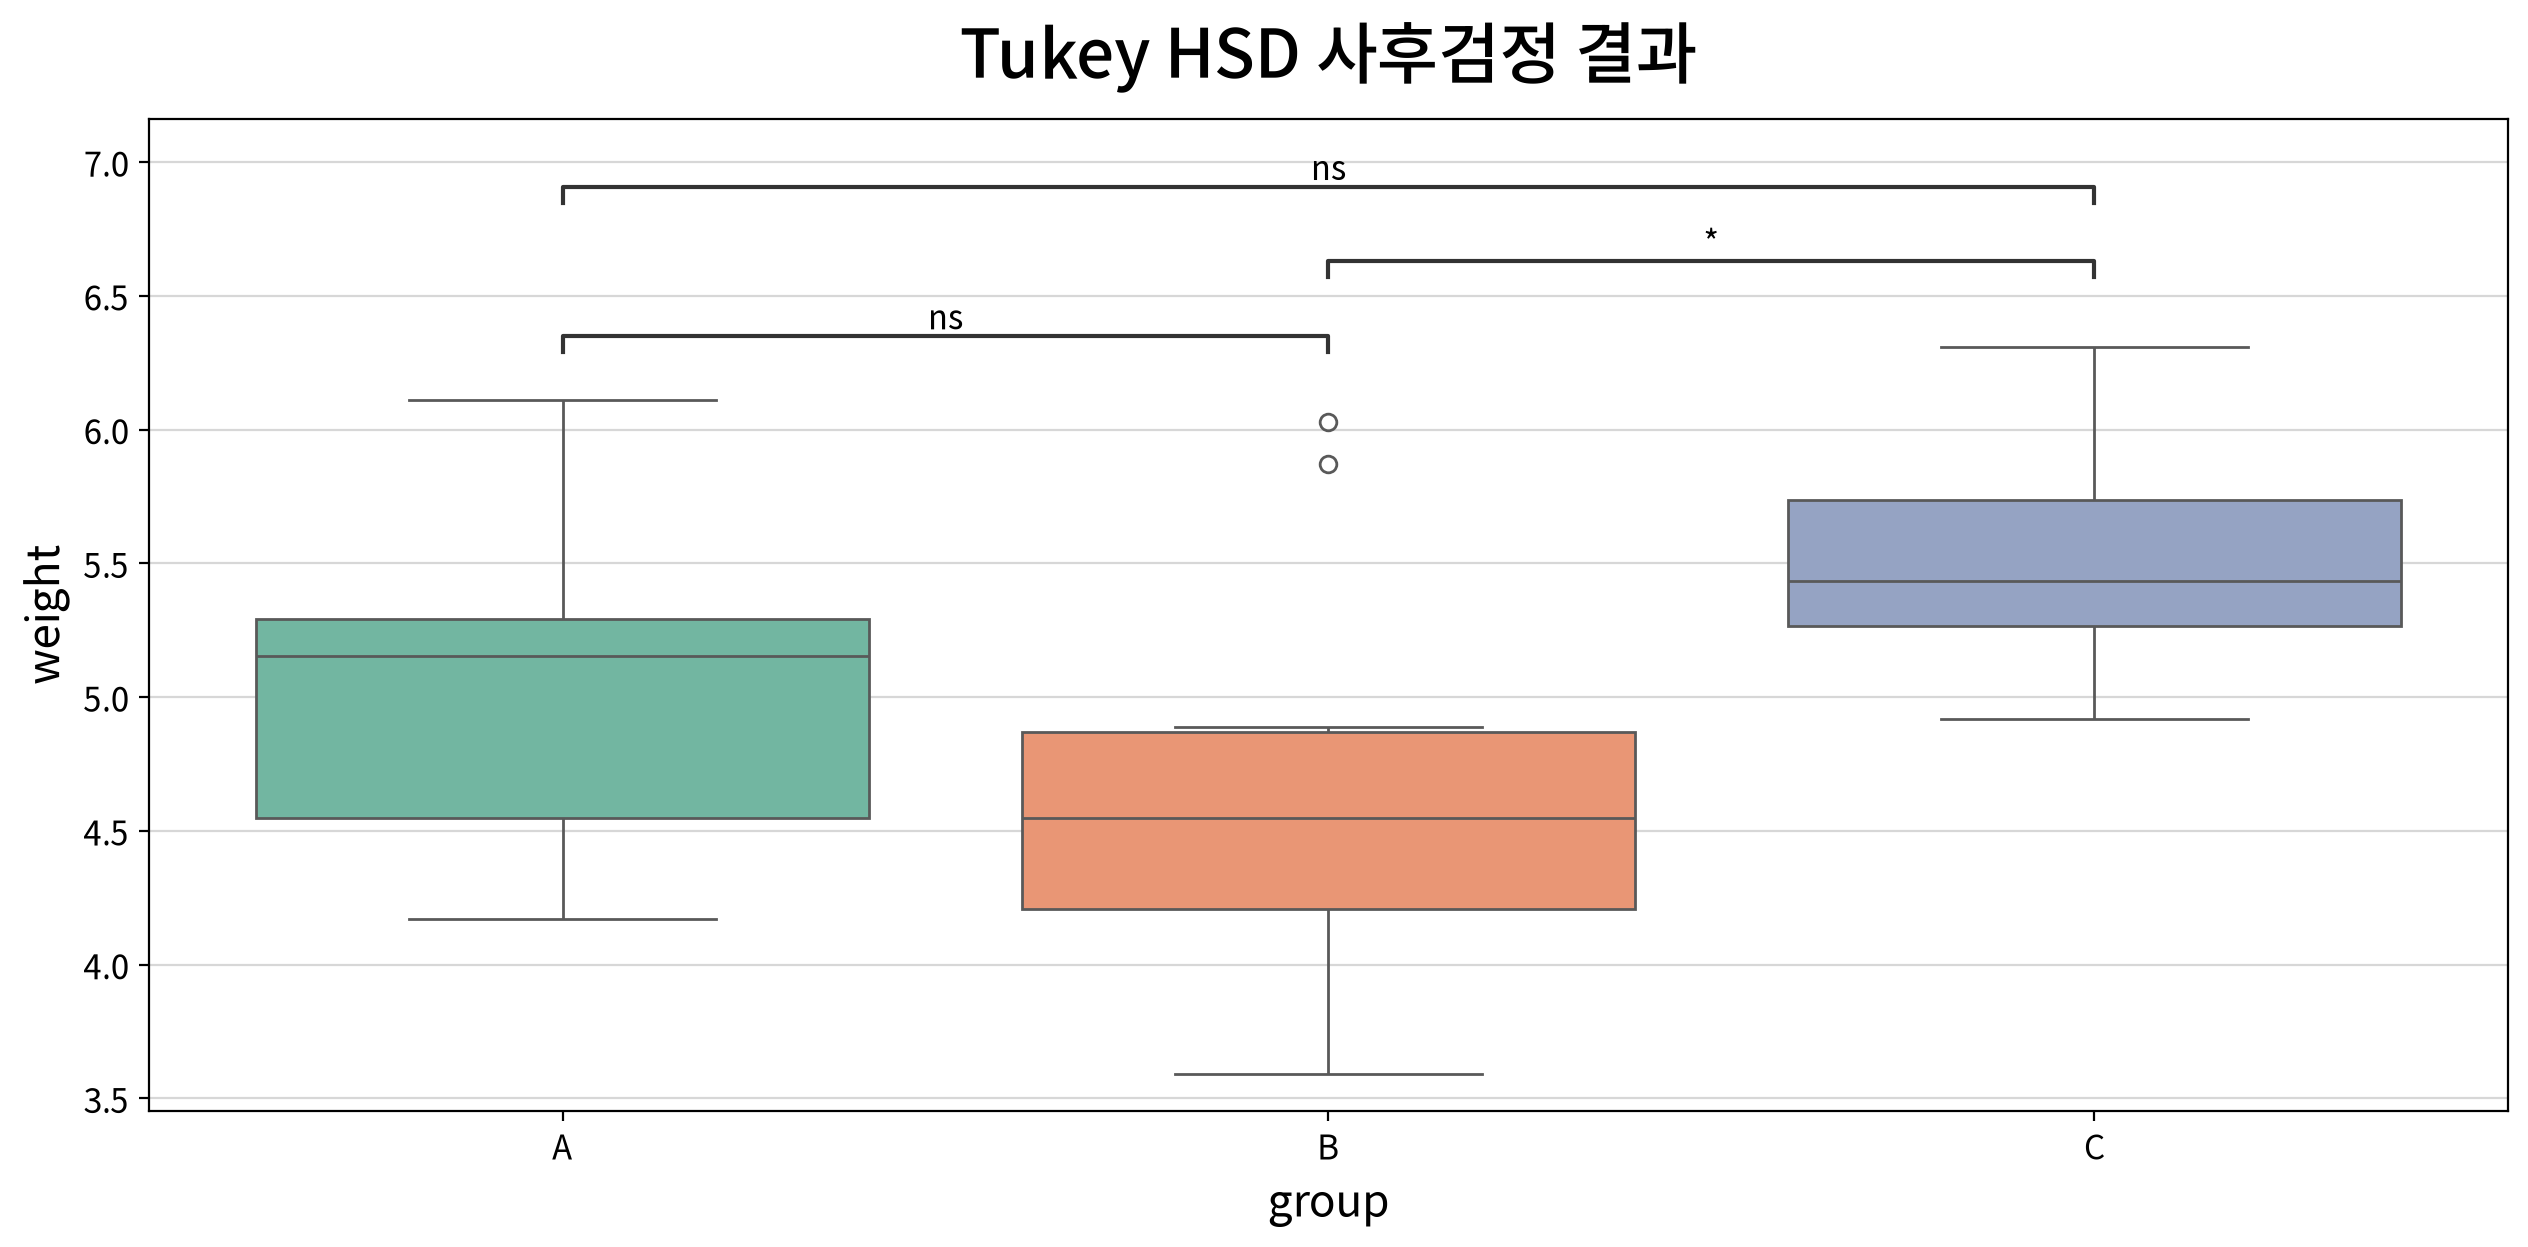

In [8]:
# 그래프 초기화
fig, ax = my_plot.init(title="Tukey HSD 사후검정 결과", xlabel="group", ylabel="weight")

# my_plot.boxplot으로 그룹별 분포 시각화
my_plot.boxplot(data=origin, x='group', y='weight', hue='group', palette='Set2', order=order, ax=ax)

# Annotator로 그룹 간 유의성(p-value) 주석을 박스플롯 위에 추가
annotator = Annotator(ax, pairs, data=origin, x='group', y='weight', order=order)

# Tukey 검정에서 구한 p값을 그대로 주입
annotator.set_pvalues(pvalues)
annotator.annotate()

# my_plot.show로 그래프 출력
my_plot.show()

## #04. 모듈화 기능 확인

### 1. 사후검정 및 결과 시각화 일괄 처리

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

A vs. B: Custom statistical test, P_val:3.909e-01
B vs. C: Custom statistical test, P_val:1.201e-02
A vs. C: Custom statistical test, P_val:1.980e-01


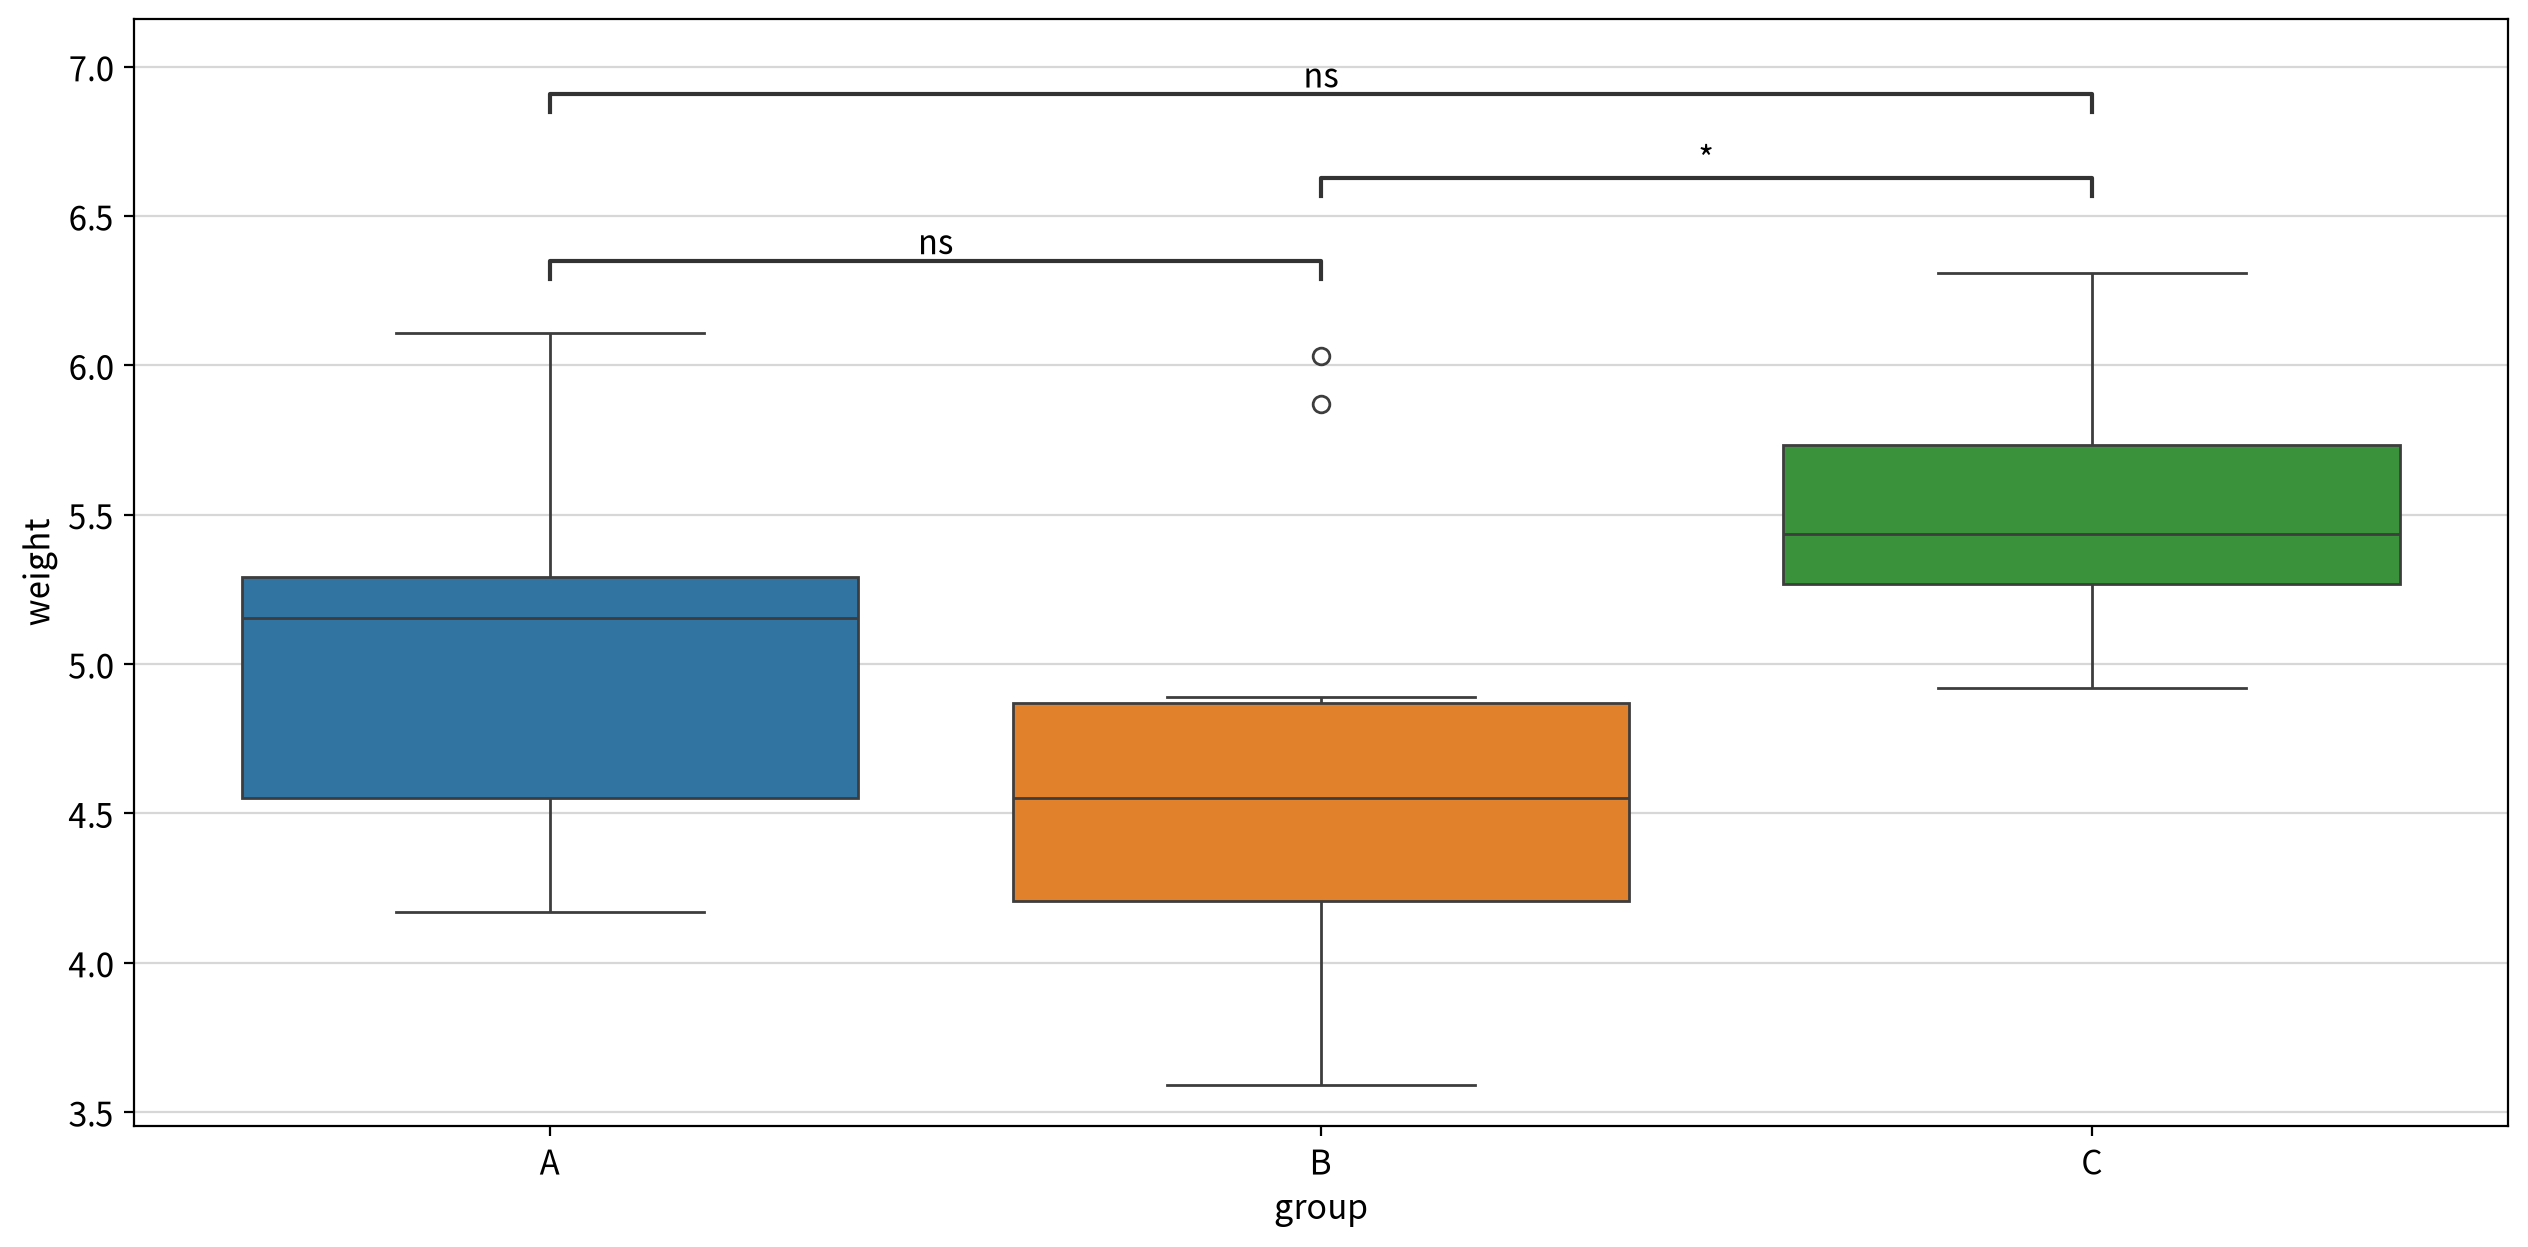

,test,A,B,mean_A,mean_B,diff,se,T,p_tukey,hedges,significant,effect_size
0,Tukey_HSD,A,B,5.032,4.661,0.371,0.279,1.331,0.391,0.510,False,Medium
1,Tukey_HSD,A,C,5.032,5.526,-0.494,0.279,-1.772,0.198,-0.914,False,Large
2,Tukey_HSD,B,C,4.661,5.526,-0.865,0.279,-3.103,0.012,-1.289,True,Large


In [9]:
my_stats.posthoc_oneway(origin, y='weight', between='group')

## 연습문제

#### 문제 1
#### 앞 단원에서 진행한 reading 데이터 셋에 대하여 세가지 독서방법에 따라
#### 독서 점수의 평균에 차이가 있다면 구체적으로 어떤 차이가 있는지 검정하라.

In [10]:
df = load_data('reading')
df.info()
df.head()

📚 유아들을 대상으로 세 가지 읽는 방법을 비교,실험하여 얻은 독서평가 점수 데이터 (출처: 방송통신대학교 통계학개론)
<class 'pandas.DataFrame'>
RangeIndex: 90 entries, 0 to 89
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   독서방법    90 non-null     str    
 1   점수      90 non-null     float64
dtypes: float64(1), str(1)
memory usage: 1.6 KB


,독서방법,점수
0,B,7.700
1,B,1.500
2,B,4.300
3,B,5.400
4,B,4.300


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

B vs. D: Custom statistical test, P_val:3.400e-01
D vs. G: Custom statistical test, P_val:4.031e-04
B vs. G: Custom statistical test, P_val:8.764e-05


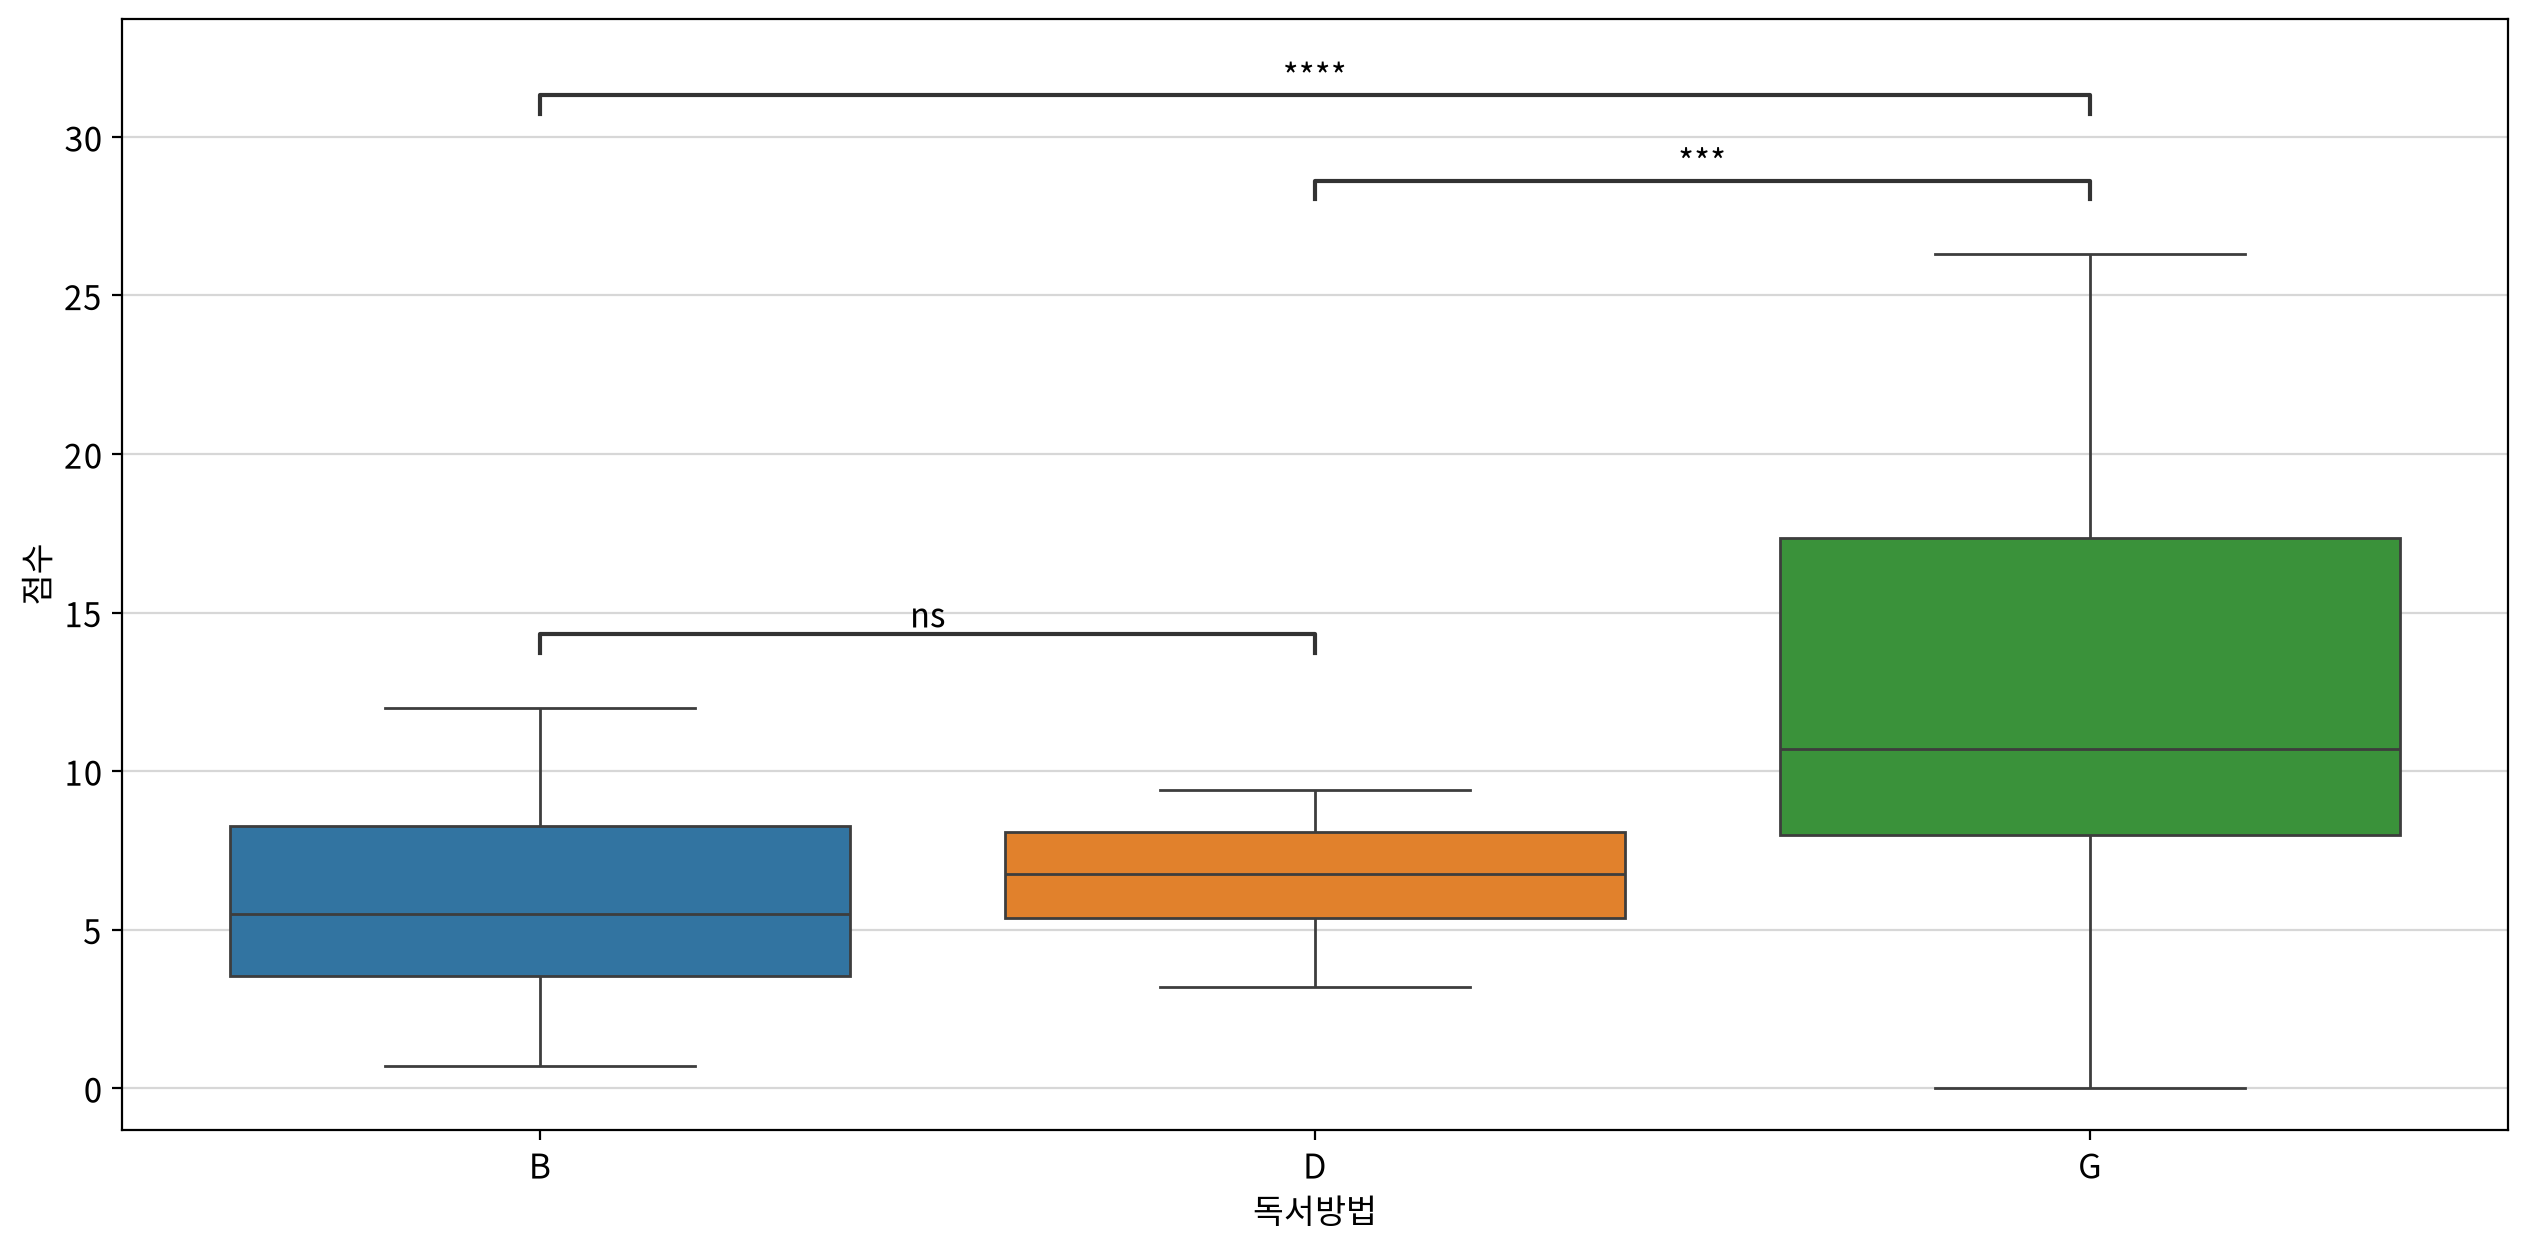

,test,A,B,mean_A,mean_B,diff,se,T,df,pval,hedges,significant,effect_size
0,Games-Howell,B,D,5.732,6.693,-0.961,0.677,-1.421,40.563,0.340,-0.376,False,Small
1,Games-Howell,B,G,5.732,12.531,-6.799,1.457,-4.666,42.964,0.000,-1.137,True,Large
2,Games-Howell,D,G,6.693,12.531,-5.838,1.363,-4.284,34.361,0.000,-1.044,True,Large


In [11]:
my_stats.posthoc_oneway(data=df, y='점수', between='독서방법')

In [12]:
my_stats.anova_oneway(df, y='점수', between='독서방법')

,test,Source,ddof1,ddof2,F,p_unc,np2,effect_size
0,welch-anova,독서방법,2,48.204,10.787,0.000,0.283,Large


## 인사이트
#### 등분산성이 충족하지 않아 Games-Howell로 사후검정 사용
#### 집단별 평균이 G(12.531) > D(6.693) > B(5.732)로 G가 가장 높음
#### 유의한 쌍은 effect_size에 Large로 표현된 B-G / D-G
#### 차이없는 쌍은 B-D

## 문제 2.
#### 앞 단원에서 진행한 2023년 서울시 상권 매출액 데이터를 사용하여 상권 종류에 따라 평균 매출액에 차이가 있다면 구체적으로 어떤 차이가 있는지 검정하라

In [13]:
df1 = load_data('commercial')
df1.info()
df1.head()

📚 서울시의 2023년 상권에 따른 분기별 매출액과 매출건수에 대한 자료 (출처: 서울 열린데이터 광장)
<class 'pandas.DataFrame'>
RangeIndex: 6222 entries, 0 to 6221
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   quarter          6222 non-null   int64
 1   code             6222 non-null   int64
 2   type             6222 non-null   str  
 3   name             6222 non-null   str  
 4   sales_amount     6222 non-null   int64
 5   number_of_sales  6222 non-null   int64
dtypes: int64(4), str(2)
memory usage: 489.8 KB


,quarter,code,type,name,sales_amount,number_of_sales
0,1,3001491,관광특구,이태원 관광특구,72523644100,2496865
1,1,3001492,관광특구,명동 남대문 북창동 다동 무교동 관광특구,283332346393,10246122
2,1,3001493,관광특구,동대문패션타운 관광특구,81696730221,2880324
3,1,3001494,관광특구,종로·청계 관광특구,212062656625,4960006
4,1,3001495,관광특구,잠실 관광특구,231338386876,5995166


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

골목상권 vs. 관광특구: Custom statistical test, P_val:6.410e-09
관광특구 vs. 발달상권: Custom statistical test, P_val:7.128e-07
발달상권 vs. 전통시장: Custom statistical test, P_val:3.927e-13
골목상권 vs. 발달상권: Custom statistical test, P_val:7.272e-14
관광특구 vs. 전통시장: Custom statistical test, P_val:1.140e-08
골목상권 vs. 전통시장: Custom statistical test, P_val:0.000e+00


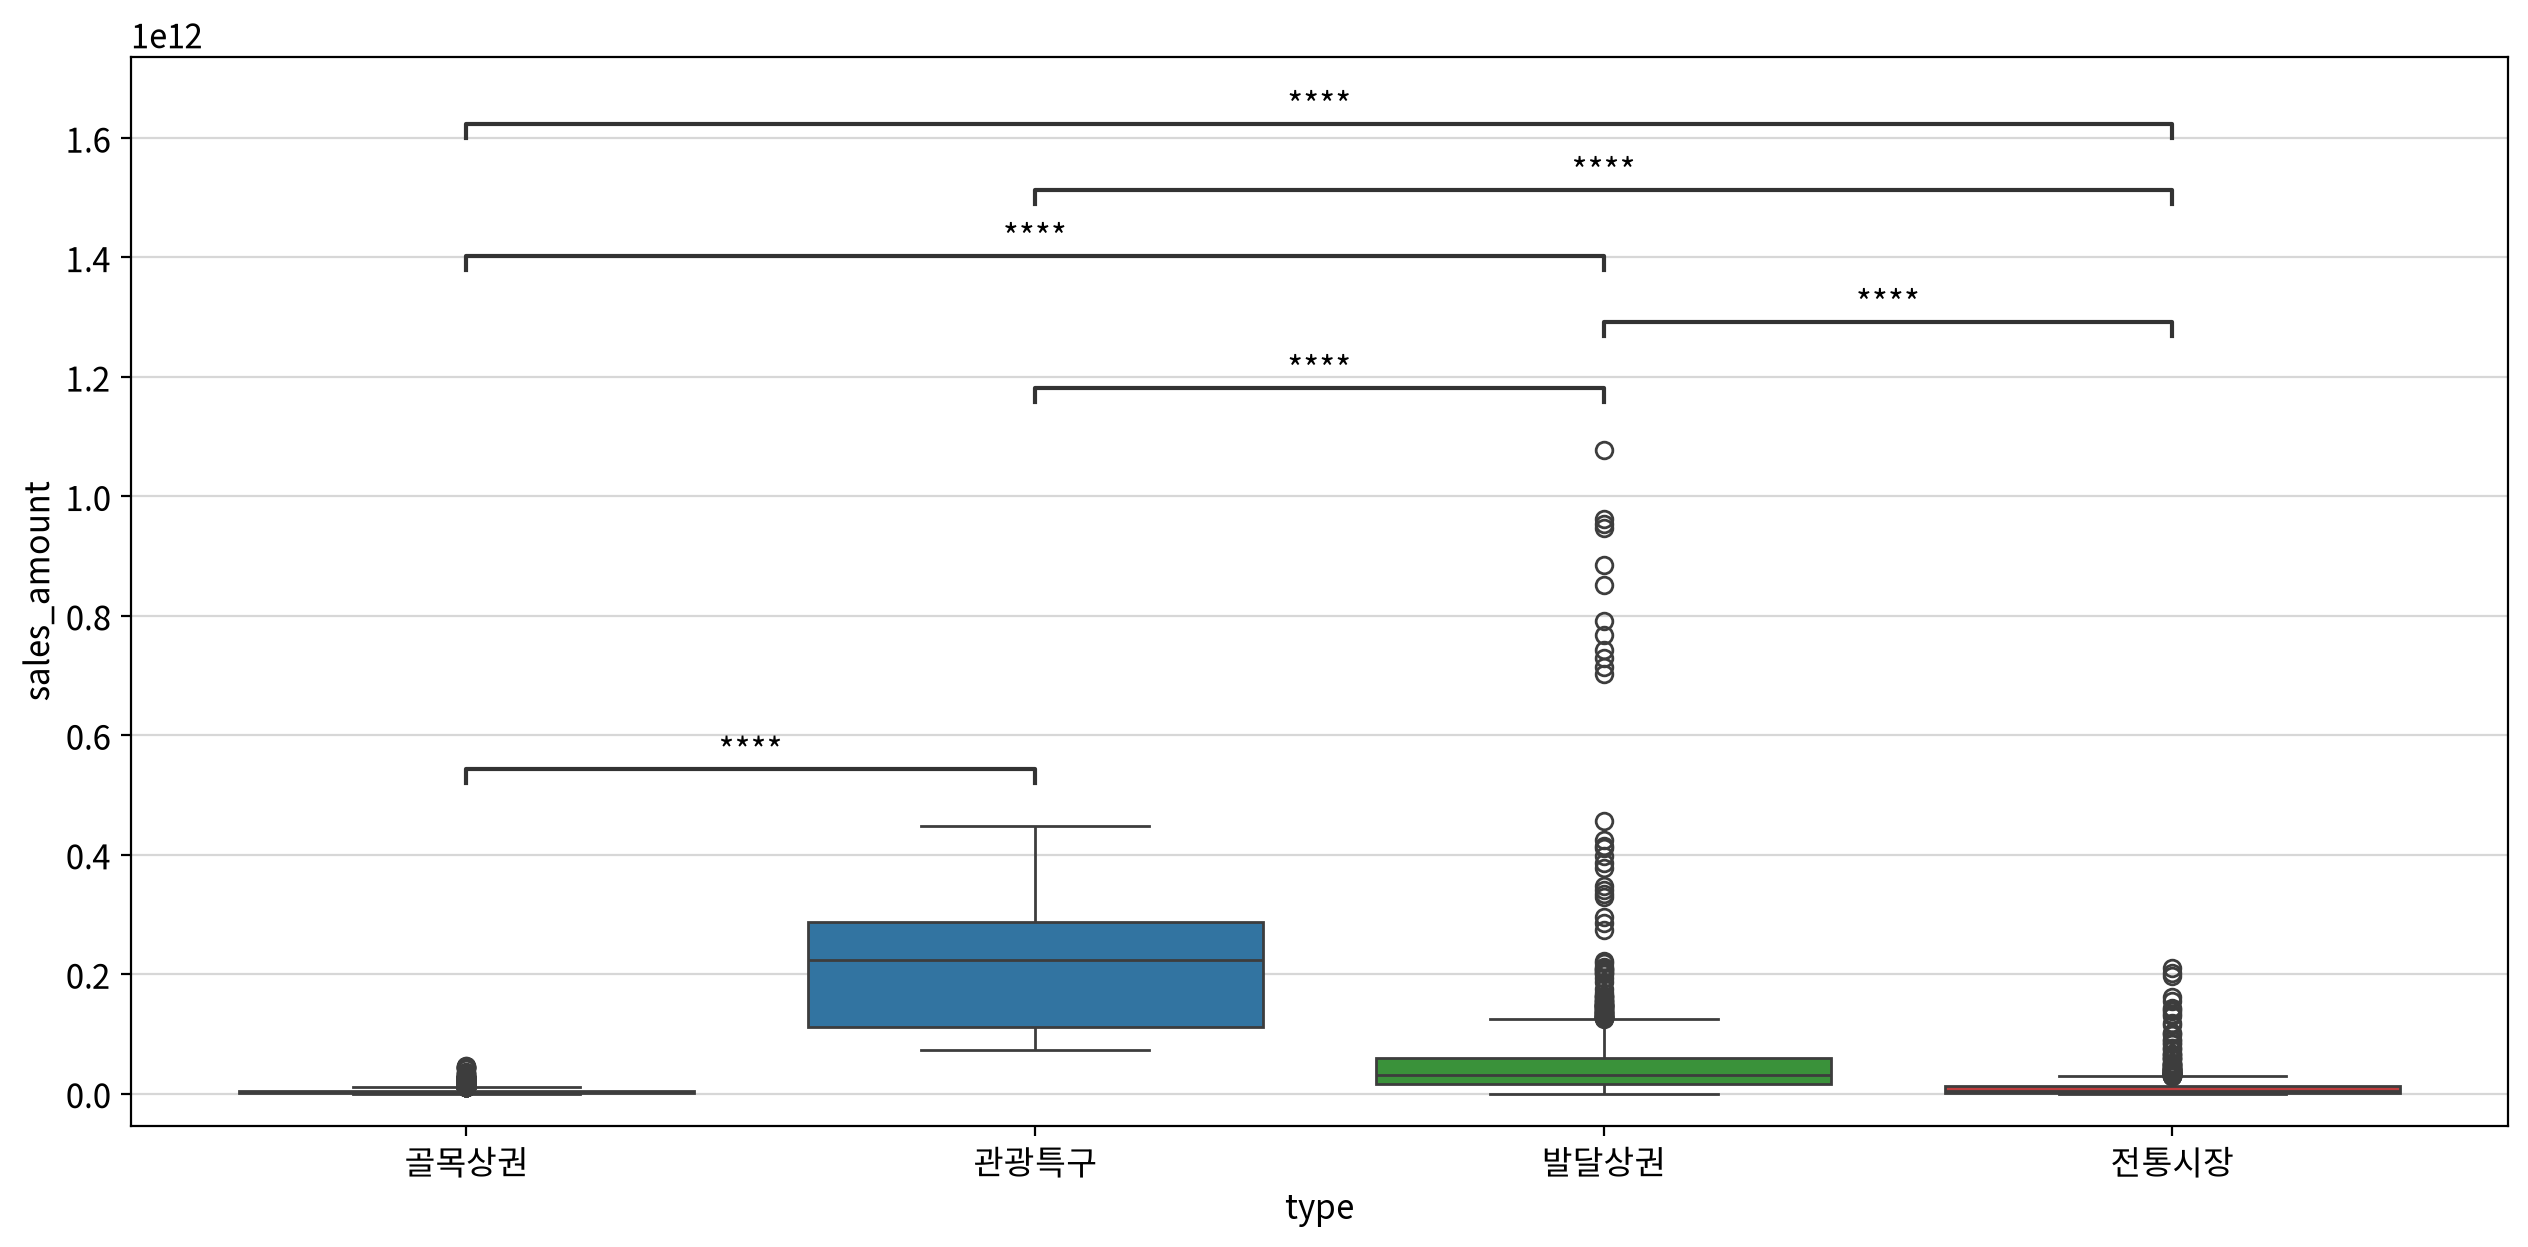

,test,A,B,mean_A,mean_B,diff,se,T,df,pval,hedges,significant,effect_size
0,Games-Howell,골목상권,관광특구,3659508698.643,228143191041.625,-224483682342.982,22892159577.450,-9.806,23.001,0.000,-23.207,True,Large
1,Games-Howell,골목상권,발달상권,3659508698.643,57063096491.533,-53403587792.891,3282877885.264,-16.267,996.055,0.000,-1.160,True,Large
2,Games-Howell,골목상권,전통시장,3659508698.643,10584197874.740,-6924689176.098,606055894.461,-11.426,1143.188,0.000,-0.679,True,Medium
3,Games-Howell,관광특구,발달상권,228143191041.625,57063096491.533,171080094550.092,23126107295.058,7.398,23.955,0.000,1.647,True,Large
4,Games-Howell,관광특구,전통시장,228143191041.625,10584197874.740,217558993166.885,22899931335.272,9.500,23.032,0.000,8.537,True,Large
5,Games-Howell,발달상권,전통시장,57063096491.533,10584197874.740,46478898616.793,3336640863.245,13.930,1061.850,0.000,0.639,True,Medium


In [14]:
my_stats.posthoc_oneway(data=df1, y='sales_amount', between='type')

## 문제 3. 
#### tips 데이터 셋은 식당 고객의 결제 금액, 팁, 성별, 흡연여부, 요일, 시간대, 일행규모 등 기본정보를 담은 데이터이다.
#### 이 데이터를 활용하여 요일별로 주문금액(total_bills)에 차이가 있는지 검정 확인하고 차이가 있다면 구체적으로 어떤 차이가 있는지 검정하라.

In [6]:
df2 = load_data('tips')
df2.info()
df2.head()

📚 식당 고객의 결제 금액, 팁, 성별, 흡연 여부, 요일, 시간대, 일행 규모 등 기본 정보를 담은 데이터 분석·시각화 실습용 샘플 데이터 (출처: https://www.kaggle.com/datasets/sakshisatre/tips-dataset)

field       description
----------  -------------
total_bill  총 결제 금액
tip         팁 금액
sex         성별
smoker      흡연 여부
day         방문 요일
time        방문 시간대
size        일행 규모

<class 'pandas.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   total_bill  244 non-null    float64
 1   tip         244 non-null    float64
 2   sex         244 non-null    str    
 3   smoker      244 non-null    str    
 4   day         244 non-null    str    
 5   time        244 non-null    str    
 6   size        244 non-null    int64  
dtypes: float64(2), int64(1), str(4)
memory usage: 17.3 KB


,total_bill,tip,sex,smoker,day,time,size
0,16.990,1.010,Female,No,Sun,Dinner,2
1,10.340,1.660,Male,No,Sun,Dinner,3
2,21.010,3.500,Male,No,Sun,Dinner,3
3,23.680,3.310,Male,No,Sun,Dinner,2
4,24.590,3.610,Female,No,Sun,Dinner,4


In [9]:
dfp = pivot_table(data=df2, index=df2.groupby('day').cumcount(), columns='day', values='total_bill', dropna=True)
dfd = dfp.dropna()
dfd

day,Fri,Sat,Sun,Thur
0,28.970,20.650,16.990,27.200
1,22.490,17.920,10.340,22.760
2,5.750,20.290,21.010,17.290
3,16.320,15.770,23.680,19.440
4,22.750,39.420,24.590,16.660
5,40.170,19.820,25.290,10.070
6,27.280,17.810,8.770,32.680
7,12.030,13.370,26.880,15.980
8,21.010,12.690,15.040,34.830
9,12.460,21.700,14.780,13.030


In [11]:
my_stats.posthoc_oneway(data=df, y='total_bill', between='day')

NameError: name 'df' is not defined

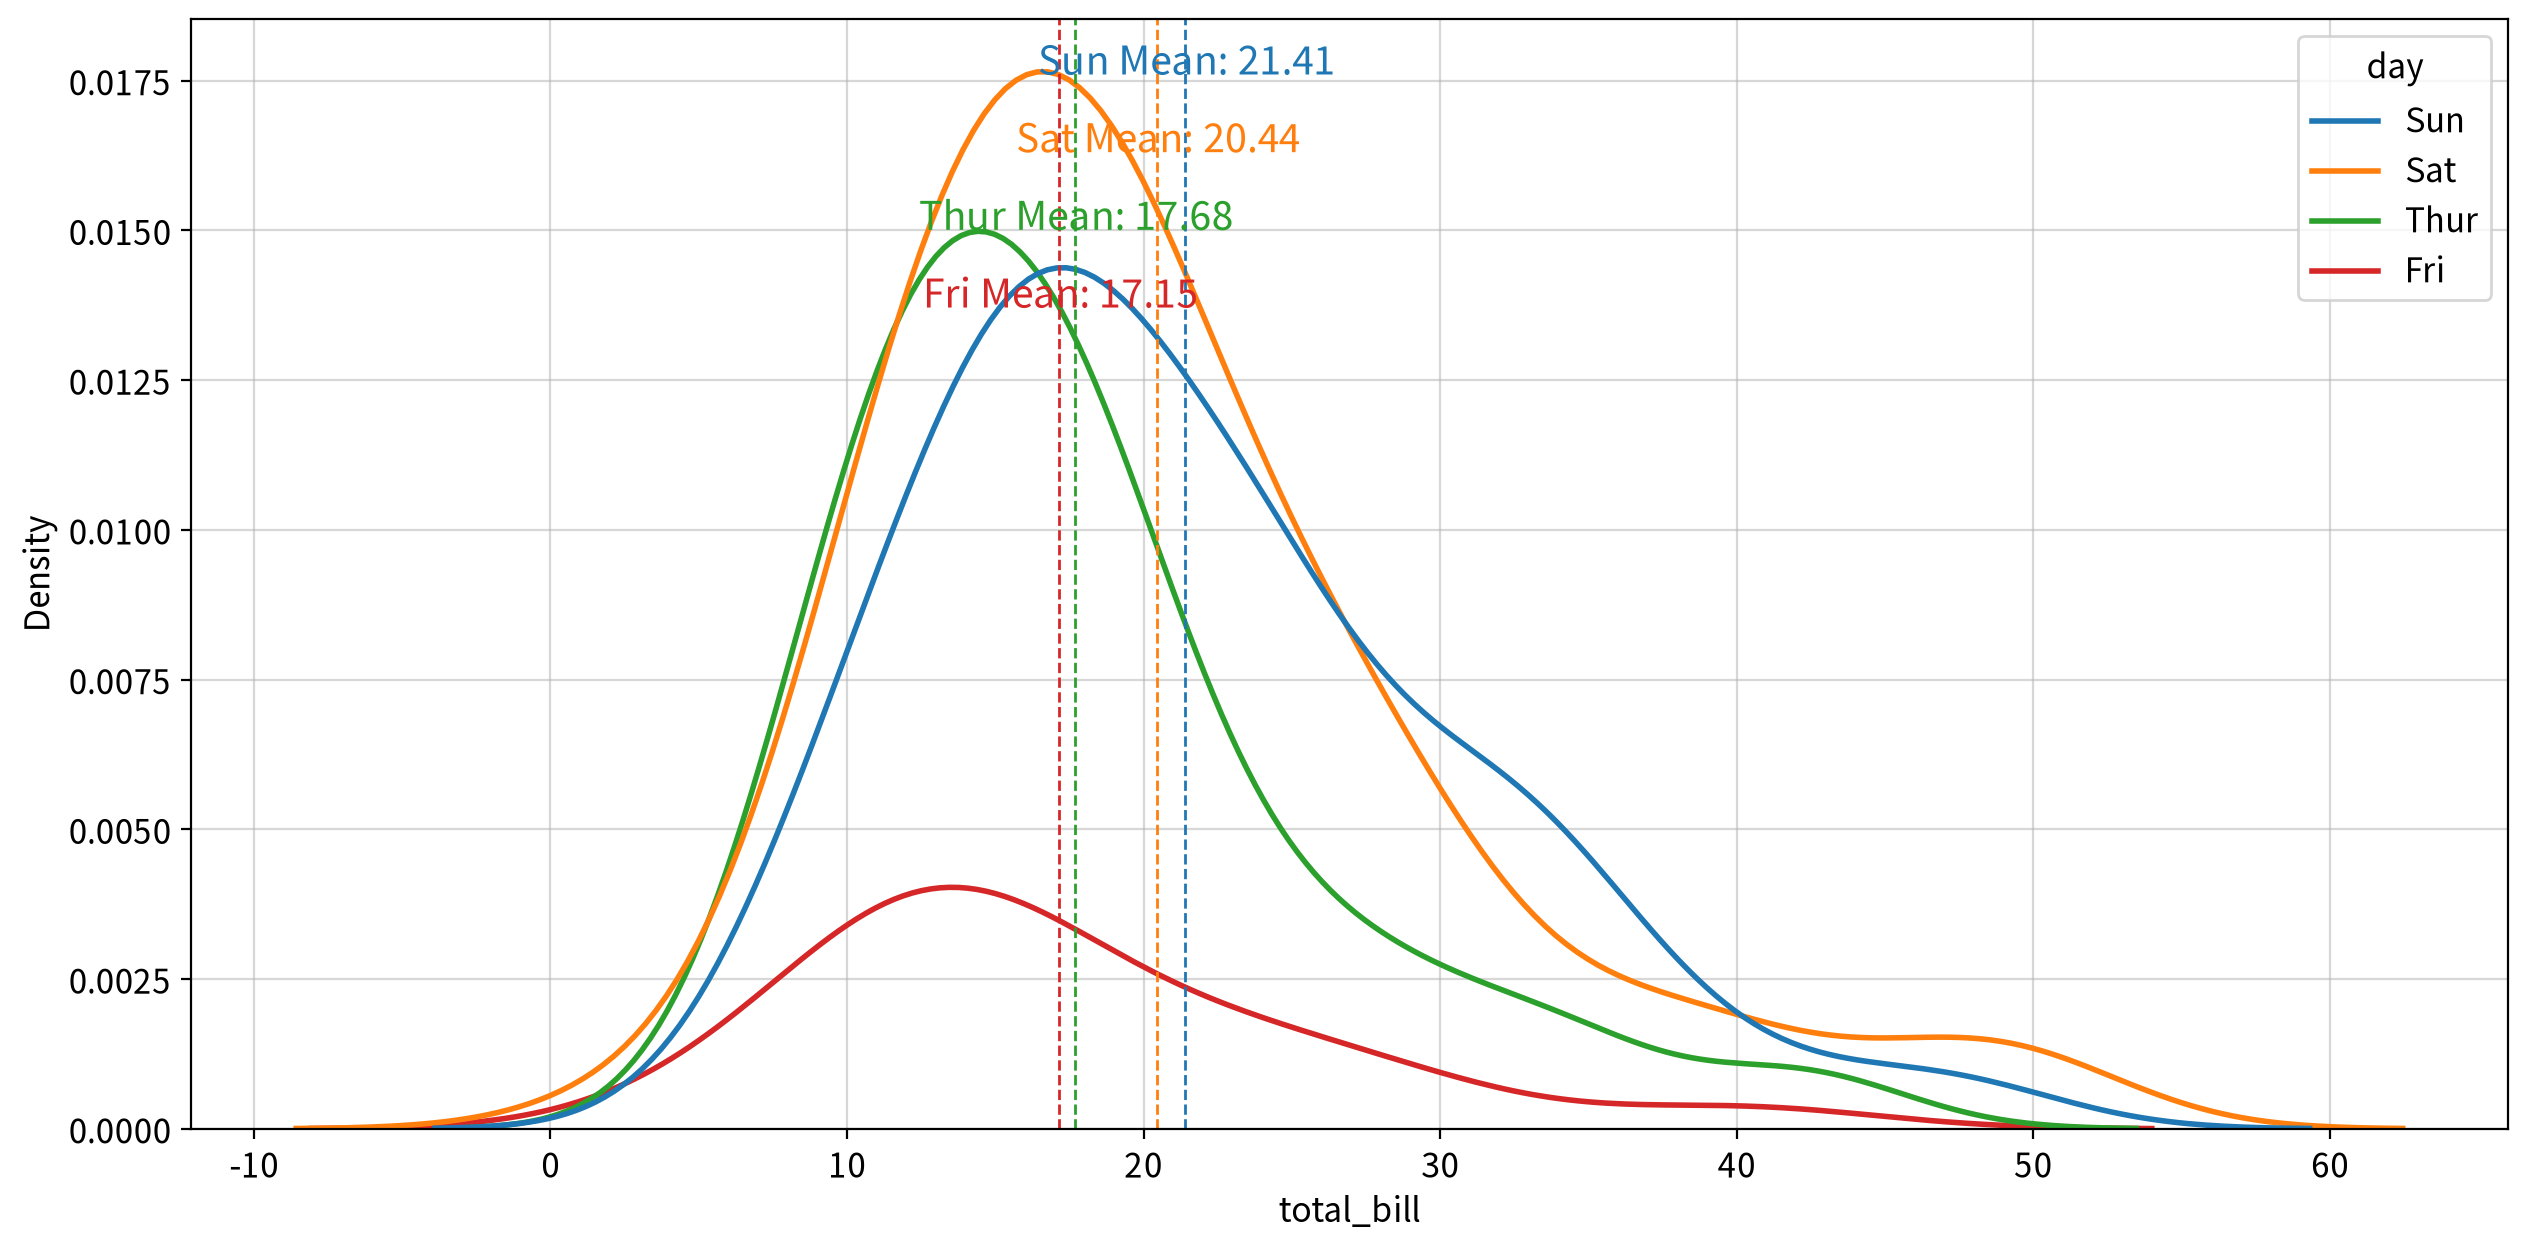

In [17]:
my_plot.kdeplot(data=df2, x='total_bill', hue='day', meanline=True)

In [18]:
my_stats.anova_oneway(data=df2, y='total_bill', between='day')

,test,Source,ddof1,ddof2,F,p_unc,np2,effect_size
0,anova,day,3,240,2.767,0.042,0.033,Small


## 문제 4. 
#### tomato 데이터 셋은 효소 성분의 비료가 효소 함량이 증가함에 따라 토마토 모종 포기의 성장에 어떤 영향을 주는지에 대한 실험 결과이다.
#### 분산분석을 하여 효소 함량에 따라 토마토 모종 성장에 차이가 나는지 검정하라.

In [19]:
df4 = load_data('tomato')
df4.info()
df4.head()

📚 효소 성분의 비료가 효소 함량이 증가함에 따라 토마토 모종 포기의 성장에 어떤 영향을 주는지에 대한 실험 결과 (출처: 방송통신대학교 통계학 개론)
<class 'pandas.DataFrame'>
RangeIndex: 90 entries, 0 to 89
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   효소함량    90 non-null     int64  
 1   모종성장    90 non-null     float64
dtypes: float64(1), int64(1)
memory usage: 1.5 KB


,효소함량,모종성장
0,0,9.500
1,0,10.000
2,0,10.700
3,0,9.000
4,0,12.400


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

0 vs. 100: Custom statistical test, P_val:7.229e-10
100 vs. 1000: Custom statistical test, P_val:9.517e-07
0 vs. 1000: Custom statistical test, P_val:2.220e-15


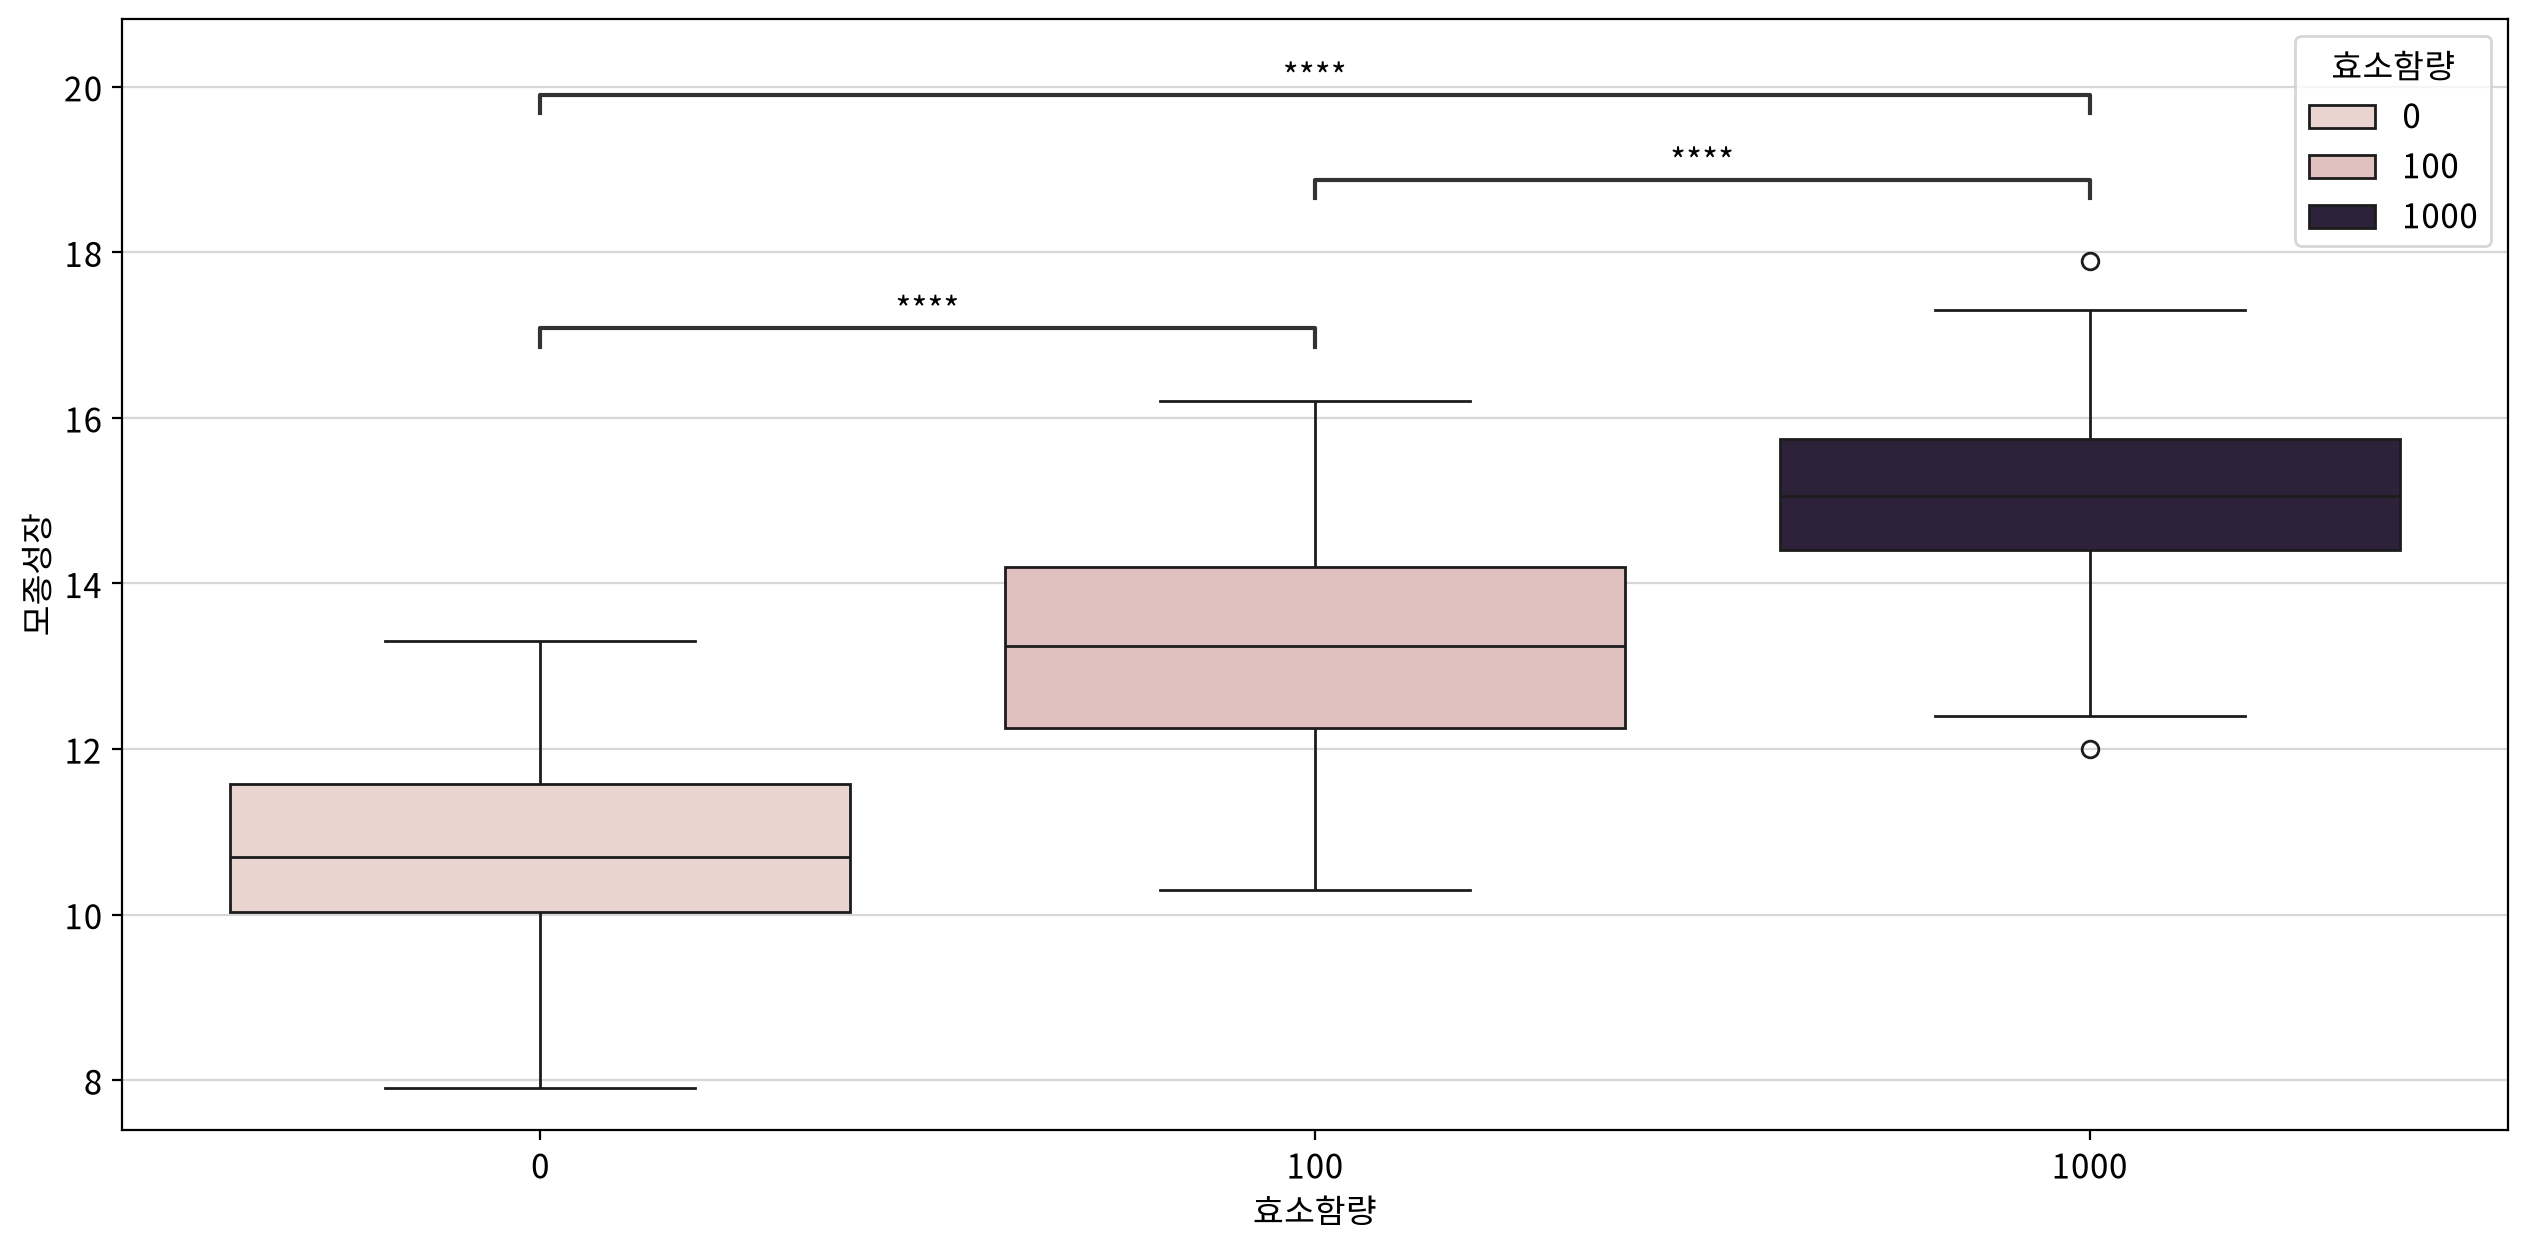

,test,A,B,mean_A,mean_B,diff,se,T,p_tukey,hedges,significant,effect_size
0,Tukey_HSD,0,100,10.753,13.180,-2.427,0.339,-7.162,0.000,-1.868,True,Large
1,Tukey_HSD,0,1000,10.753,15.057,-4.303,0.339,-12.701,0.000,-3.316,True,Large
2,Tukey_HSD,100,1000,13.180,15.057,-1.877,0.339,-5.539,0.000,-1.351,True,Large


In [20]:
my_stats.posthoc_oneway(data=df4, y='모종성장', between='효소함량')

In [21]:
my_stats.anova_oneway(data=df4, y='모종성장', between='효소함량')

,test,Source,ddof1,ddof2,F,p_unc,np2,effect_size
0,anova,효소함량,2,87,81.094,0.000,0.651,Large


### 인사이트
##### 가정확인 : test는 Tukey_HSD로 출력으로 등분산성가정이 충족
##### p_value가 0.000 으로 유의수준보다 0.05보다 작아 귀무가설은 기각.
##### np2(부분 에타제곱)이 0.651로 큰 효과로 해석됨. 효소함량이 모종성장 분산의 약 65.1%를 설명
##### 분산분석결과 : 0-100 / 0-1000 / 100-1000 모두다 연관이 있음.
##### 효소 함량에 따라 모종성장이 유의하고 큰 차이를 만듬.